In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Configuration affichage
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
products = pd.read_csv("products.csv")

print(f"Orders : {orders.shape}")
print(f"Products : {products.shape}")
orders.head()

Orders : (30000, 13)
Products : (49, 4)


,order_id,customer_id,order_date,customer_state,customer_city,product_id,product_category,price,freight_value,payment_type,n_installments,delivery_days,review_score
0,O029800,C11951,2023-01-01,RJ,Petropolis,P0004,electronique,427.77,28.34,credit_card,2,5,5
1,O021225,C11798,2023-01-01,SP,Guarulhos,P0016,maison,169.26,17.84,credit_card,6,4,4
2,O016127,C05355,2023-01-01,RJ,Rio de Janeiro,P0041,jouets,47.17,10.69,credit_card,3,5,5
3,O025785,C01929,2023-01-01,SP,Sao Paulo,P0013,maison,17.73,8.51,boleto,1,4,4
4,O017692,C10629,2023-01-01,MG,Juiz de Fora,P0010,mode,14.54,9.33,debit_card,1,8,5


In [6]:
#permet d'afficher les types de chaque colonne 
orders.dtypes


order_id                       str
customer_id                    str
order_date          datetime64[us]
customer_state                 str
customer_city                  str
product_id                     str
product_category               str
price                      float64
freight_value              float64
payment_type                   str
n_installments               int64
delivery_days                int64
review_score                 int64
dtype: object

In [7]:
orders.describe()
#permet d'afficher les values comme min max ecart type et les quartiles


,order_date,price,freight_value,n_installments,delivery_days,review_score
count,30000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000
mean,2023-12-31 02:46:59.520000,129.543473,15.776045,2.34200,5.527833,4.119033
min,2023-01-01 00:00:00,7.240000,7.540000,1.00000,1.000000,1.000000
25%,2023-07-04 00:00:00,33.750000,10.040000,1.00000,3.000000,4.000000
50%,2023-12-30 00:00:00,72.270000,12.810000,1.00000,5.000000,4.000000
75%,2024-06-29 00:00:00,161.302500,17.580000,3.00000,8.000000,5.000000
max,2024-12-30 00:00:00,746.700000,68.170000,10.00000,19.000000,5.000000
std,NaN,150.388019,8.698926,2.18223,3.215479,0.992185


Le prix moyen d'une commande est de 129,54 BRL, avec des valeurs allant de 7,24 BRL a 746,70 BRL, sans valeurs aberrantes evidentes (pas de prix negatif ou nul).

L'ecart-type, qui mesure la dispersion des valeurs autour de la moyenne, est de 150,39 BRL, soit un ecart-type superieur a la moyenne. Cela indique une forte dispersion des prix : le prix des commandes varie enormement d'un extreme a l'autre.

On observe egalement un ecart notable entre la moyenne (129,54 BRL) et la mediane (72,27 BRL, soit Q2) : la moyenne est nettement plus elevee. Cela revele une distribution asymetrique a droite : la moitie inferieure des prix est resserree (de 7 a 72 BRL), tandis que la moitie superieure s'etale beaucoup plus largement (de 72 a 746 BRL). Cette trainee de commandes a prix eleve tire la moyenne vers le haut.

Conclusion : le prix median (72 BRL) reflete mieux la commande typique que la moyenne.

In [8]:
orders["review_score"].value_counts().sort_index()
#permet d'afficher le nombre de personnes ayant mis une note précise. l'affichage se fait de la pire note (1) à la meilleure (5)


review_score
1      554
2     1820
3     4409
4     9935
5    13282
Name: count, dtype: int64

In [9]:
orders["review_score"].value_counts(normalize=True).sort_index() * 100
#permet d'obtenir une distribution des notes en %

review_score
1     1.846667
2     6.066667
3    14.696667
4    33.116667
5    44.273333
Name: proportion, dtype: float64

La distribution des notes est fortement positive avec une moyenne des notes de 4,11 : 77,4% des clients attribuent une note de 4 ou 5 étoiles (dont 44,3% donnent la note maximale). À l'inverse, seuls 7,9% des clients laissent une note de 1 ou 2 étoiles, traduisant une réelle insatisfaction. Les notes neutres (3 étoiles) représentent 14,7% des avis.

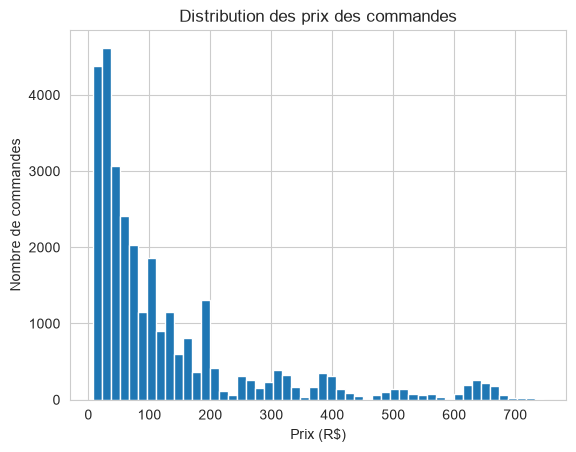

In [10]:
plt.hist(orders["price"], bins=50)
plt.title("Distribution des prix des commandes")
plt.xlabel("Prix (R$)")
plt.ylabel("Nombre de commandes")
plt.show()

L'histogramme confirme l'asymetrie a droite observee dans les statistiques descriptives : la majorite des commandes se situent entre 0 et 200 BRL, avec un pic tres marque autour de 25-50 BRL. Au-dela de 200 BRL, la frequence des commandes diminue fortement mais une trainee s'etend jusqu'a environ 750 BRL, expliquant l'ecart entre la moyenne (129,54 BRL) et la mediane (72,27 BRL).

In [11]:
orders["product_category"].value_counts().head(10)
#permet de selectionner la colonne produt_category de orders et de compter combien y'a de commandes par category pour sortir in fine les 10 categories avec le + de commandes

product_category
beaute          4309
electronique    4256
sport           4188
alimentation    3707
livres          3681
maison          3661
jouets          3138
mode            3060
Name: count, dtype: int64

In [14]:
orders["product_category"].value_counts(normalize=True).head(10)*100
#permet d'afficher la distribution de chaque categorie en %

product_category
beaute          14.363333
electronique    14.186667
sport           13.960000
alimentation    12.356667
livres          12.270000
maison          12.203333
jouets          10.460000
mode            10.200000
Name: proportion, dtype: float64

Le dataset comporte 8 categories de produits, avec une repartition relativement equilibree en volume de commandes : beaute (14,4%), electronique (14,2%) et sport (14,0%) suivies de alimentation, livres et maison (~12% chacune), puis jouets et mode (~10% chacune).

In [16]:
orders["customer_state"].value_counts()
#permet d'afficher le nombre de clients ainsi que de commandes par pays. 

customer_state
SP    10622
RJ     4337
MG     3268
BA     2407
RS     2079
PR     1943
PE     1643
PA     1388
CE     1275
SC     1038
Name: count, dtype: int64

In [18]:
orders["customer_state"].value_counts(normalize=True)*100

customer_state
SP    35.406667
RJ    14.456667
MG    10.893333
BA     8.023333
RS     6.930000
PR     6.476667
PE     5.476667
PA     4.626667
CE     4.250000
SC     3.460000
Name: proportion, dtype: float64

SP concentre a elle seule plus d'un tiers des commandes (35,4%), loin devant Rio (14,5%) et Minas Gerais (10,9%). A eux trois ces etats representent deja plus de 60% du volume total.
Cote business, ca donne une bonne indication sur ou concentrer les efforts logistiques en priorite (entrepots, transporteurs) : SP, RJ et MG en premier.